# Softmax experiment
## Attention_nu_int_dim_20260422.ipynb
## consider a range of alphas. Generate W with tail exponent alpha
## calculate PP(W)
## attnW = softmax(W / sqrt(d))
## calculate PP(attnW)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [3]:
import PatnaikPearson as pp
import cupy

In [3]:
# combine these sets
arr1 = np.arange(0.05, 0.3, 0.01) # 25
arr2 = np.arange(0.3, 0.7, 0.02) # 20
arr3 = np.arange(0.7, 1.0, 0.03) # 10
arr4 = np.arange(1.0, 2.0, 0.05) # 20
arr5 = np.arange(2.0, 5.1, 0.05) # 40
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))

In [ ]:
print(len(combined))

In [ ]:
these_alphas = combined #np.arange(0.05,2.05,0.05)
num_values = len(these_alphas)

alpha_vals = np.zeros(num_values)
implied_alpha_W_vals = np.zeros(num_values)
implied_alpha_softmaxW = np.zeros(num_values)
actual_nu_W_over_d_vals = np.zeros(num_values)
actual_alpha_softmaxW_vals = np.zeros(num_values)
estimated_alpha_softmaxW_vals = np.zeros(num_values)
actual_nu_softmaxW_over_d_vals = np.zeros(num_values)
implied_nu_softmaxW_over_d_vals = np.zeros(num_values)

d = 1000

i = 0
for this_alpha in these_alphas: # in range(5):

  #this_alpha = 1.0 + (0.5 * i)
  #this_alpha = 0.5 + (0.01 * i)
  alpha_vals[i] = this_alpha

  W = pp.generate_square_weight_matrix(d, this_alpha)

  actual_nu_W_over_d = pp.calculate_PatnaikPearson_dim(W) / d
  actual_nu_W_over_d_vals[i] = actual_nu_W_over_d

  implied_alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_W_over_d, d)
  implied_alpha_W_vals[i] = implied_alpha_W

  softmaxW = pp.row_wise_softmax(W / math.sqrt(d))

  actual_nu_softmaxW_over_d = pp.calculate_PatnaikPearson_dim(softmaxW) / d
  actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d

  actual_alpha_softmaxW = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxW_over_d, d)
  actual_alpha_softmaxW_vals[i] = actual_alpha_softmaxW

  estimated_alpha_softmaxW = pp.calculate_softmax_alpha(implied_alpha_W)
  estimated_alpha_softmaxW_vals[i] = estimated_alpha_softmaxW

  implied_nu_softmaxW_over_d = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxW, d)
  implied_nu_softmaxW_over_d_vals[i] = implied_nu_softmaxW_over_d

  print(i, "this_alpha = ", this_alpha)
  print(i, "implied_alpha_W = ", implied_alpha_W)
  print(i, "actual_alpha_softmaxW = ", actual_alpha_softmaxW)
  print(i, "estimated_alpha_softmaxW = ", estimated_alpha_softmaxW)
  print(i, "actual_nu_softmaxW_over_d = ", actual_nu_softmaxW_over_d)
  print(i, "implied_nu_softmaxW_over_d = ", implied_nu_softmaxW_over_d)

  #print(i, this_alpha, implied_alpha_W,  actual_alpha_softmaxW, estimated_alpha_softmaxW, actual_nu_softmaxW_over_d, implied_nu_softmaxW_over_d)
  i +=1

In [ ]:
xx = [1,2.5,3]
print(xx)
print(np.array(xx) - 1.0)

In [ ]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)

plt.plot(alpha_vals, alpha_vals, label = "alpha")
plt.plot(alpha_vals, actual_alpha_softmaxW_vals, label = "softmax alpha (actual)")
plt.plot(alpha_vals, estimated_alpha_softmaxW_vals, label = "softmax alpha (estimated)")
plt.xlabel("alpha")
plt.ylabel("softmax alpha")
plt.title(this_title)
plt.legend()
plt.show()

In [ ]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)

plt.plot(implied_alpha_W_vals, implied_alpha_W_vals, label = "alpha")
plt.scatter(implied_alpha_W_vals, actual_alpha_softmaxW_vals, label = "softmax alpha (actual)")
plt.scatter(implied_alpha_W_vals, estimated_alpha_softmaxW_vals, label = "softmax alpha (estimated)")
plt.xlabel("alpha")
plt.ylabel("softmax alpha")
plt.title(this_title)
plt.legend()
plt.savefig('pp_softmax_one.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)
k = 80
plt.plot(implied_alpha_W_vals[0:k], implied_alpha_W_vals[0:k], label = "alpha")
#plt.plot(implied_alpha_W_vals[0:k], implied_alpha_W_vals[0:k], label = "implied alpha")
#plt.plot(alpha_vals[0:k], softmax_alpha_vals[0:k], label = "softmax alpha")
plt.scatter(implied_alpha_W_vals[0:k], actual_alpha_softmaxW_vals[0:k], label = "softmax alpha (actual)")
plt.scatter(implied_alpha_W_vals[0:k], estimated_alpha_softmaxW_vals[0:k], label = "softmax alpha (estimated)")
plt.xlabel("alpha(W)")
plt.ylabel("alpha softmax(W)")
plt.title(this_title)
plt.legend()
plt.savefig('pp_softmax_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
np_actual_nu_W_over_d_vals = np.zeros(len(actual_nu_W_over_d_vals))
for i in range(len(actual_nu_W_over_d_vals)):
    np_actual_nu_W_over_d_vals[i] = actual_nu_W_over_d_vals[i]

np_actual_nu_softmaxW_over_d_vals = np.zeros(len(actual_nu_softmaxW_over_d_vals))
for i in range(len(actual_nu_softmaxW_over_d_vals)):
    np_actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d_vals[i]
    
this_title = "nu(softmax(W / sqrt(d)))/ d, as nu(W) varies. d = " + str(d)
plt.scatter(np_actual_nu_W_over_d_vals, np_actual_nu_softmaxW_over_d_vals, label = "nu(softmax(W / sqrt(d)))/ d (actual)")
plt.scatter(np_actual_nu_W_over_d_vals, implied_nu_softmaxW_over_d_vals, label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.xlabel("nu(W) / d")
plt.ylabel("nu(softmax W) / d")
plt.legend()
plt.title(this_title)
plt.show()

k = 70
plt.scatter(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W/sqrt(d)))/d (actual)")
#plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.scatter(np_actual_nu_W_over_d_vals[0:k], implied_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.plot(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.xlabel("nu(W)/d")
plt.ylabel("nu(softmax W)/d")
plt.legend()
plt.title(this_title)
plt.show()

k = 50
plt.scatter(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W/sqrt(d)))/d (actual)")
#plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.scatter(np_actual_nu_W_over_d_vals[0:k], implied_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.plot(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.xlabel("nu(W)/d")
plt.ylabel("nu(softmax W)/d")
plt.legend()
plt.title(this_title)
plt.show()

In [ ]:
print("alpha_vals = ", alpha_vals[0:100])
print()
#print("softmax_alpha_vals = ", softmax_alpha_vals[0:100])
print("actual_alpha_softmaxW_vals = ", actual_alpha_softmaxW_vals[0:100])
print()

# New approach. X is N * d
## N = 1000, d = 500

In [16]:

these_alphas = combined 
num_values = len(these_alphas)

alpha_vals = np.zeros(num_values)
implied_alpha_X_vals = np.zeros(num_values)
implied_alpha_softmaxX = np.zeros(num_values)
actual_nu_X_over_d_vals = np.zeros(num_values)
actual_alpha_softmaxX_vals = np.zeros(num_values)
estimated_alpha_softmaxX_vals = np.zeros(num_values)
actual_nu_softmaxX_over_d_vals = np.zeros(num_values)
estimated_nu_softmaxX_over_d_vals = np.zeros(num_values)

N = 1000
d = 500
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False
use_svd = True

i = 0
for this_alpha in these_alphas:

  alpha_vals[i] = this_alpha

  X = pp.generate_data_manifold(N, d, this_alpha, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose, use_svd)

  actual_nu_X_over_d = pp.calculate_PatnaikPearson_dim(X) / d
  actual_nu_X_over_d_vals[i] = actual_nu_X_over_d

  implied_alpha_X = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_X_over_d, d)
  implied_alpha_X_vals[i] = implied_alpha_X

  softmaxX = pp.row_wise_softmax(X / math.sqrt(d))

  actual_nu_softmaxX_over_d = pp.calculate_PatnaikPearson_dim(softmaxX) / d
  actual_nu_softmaxX_over_d_vals[i] = actual_nu_softmaxX_over_d

  actual_alpha_softmaxX = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxX_over_d, d)
  actual_alpha_softmaxX_vals[i] = actual_alpha_softmaxX

  estimated_alpha_softmaxX = pp.calculate_softmax_alpha(implied_alpha_X)
  estimated_alpha_softmaxX_vals[i] = estimated_alpha_softmaxX

  estimated_nu_softmaxX_over_d = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxX, d)
  estimated_nu_softmaxX_over_d_vals[i] = estimated_nu_softmaxX_over_d

  print(i, "this_alpha = ", this_alpha)
  print(i, "implied_alpha_X = ", implied_alpha_X)
  print(i, "actual_alpha_softmaxX = ", actual_alpha_softmaxX)
  print(i, "estimated_alpha_softmaxX = ", estimated_alpha_softmaxX)
  print(i, "actual_nu_X_over_d = ", actual_nu_X_over_d)
  print(i, "actual_nu_softmaxX_over_d = ", actual_nu_softmaxX_over_d)
  print(i, "estimated_nu_softmaxX_over_d = ", estimated_nu_softmaxX_over_d)

  #print(i, this_alpha, implied_alpha_X,  actual_alpha_softmaxX, estimated_alpha_softmaxX, actual_nu_softmaxX_over_d, implied_nu_softmaxX_over_d)
  i +=1

generate_data_manifold: using svd
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 this_alpha =  0.05
0 implied_alpha_X =  0.2928936806874944
0 actual_alpha_softmaxX =  0.29289334338236966
0 estimated_alpha_softmaxX =  0.293526326559826
0 actual_nu_X_over_d =  0.0020000038161401296
0 actual_nu_softmaxX_over_d =  0.0020000000000000074
0 estimated_nu_softmaxX_over_d =  0.002007171146647376
generate_data_manifold: using svd
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
1 this_alpha =  0.060000000000000005
1 implied_alpha_X =  0.2928967473403099
1 actual_alpha_softmaxX =  0.292893343382371
1 estimated_alpha_softmaxX =  0.2946395691084788
1 actual_nu_X_over_d =  0.002000038511318128
1 actual_nu_softmaxX_over_d =  0.002000000000000022
1 estimated_nu_softmaxX_over_d =  0.002019829737088778
generate_data_man

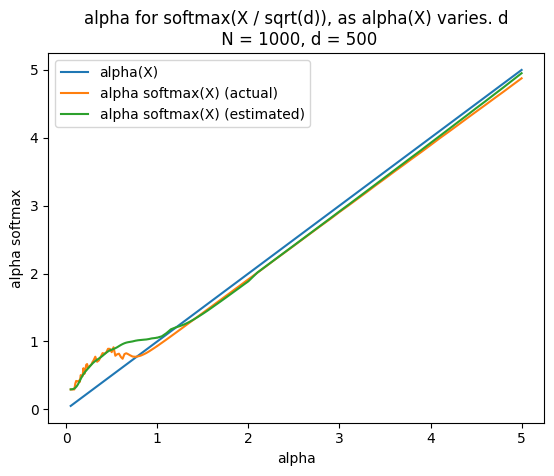

In [17]:

this_title = "alpha for softmax(X / sqrt(d)), as alpha(X) varies. d\n N = " + str(N) + ", d = " + str(d)

plt.plot(alpha_vals, alpha_vals, label = "alpha(X)")
plt.plot(alpha_vals, actual_alpha_softmaxX_vals, label = "alpha softmax(X) (actual)")
plt.plot(alpha_vals, estimated_alpha_softmaxX_vals, label = "alpha softmax(X) (estimated)")
plt.xlabel("alpha")
plt.ylabel("alpha softmax")
plt.title(this_title)
plt.legend()
plt.show()

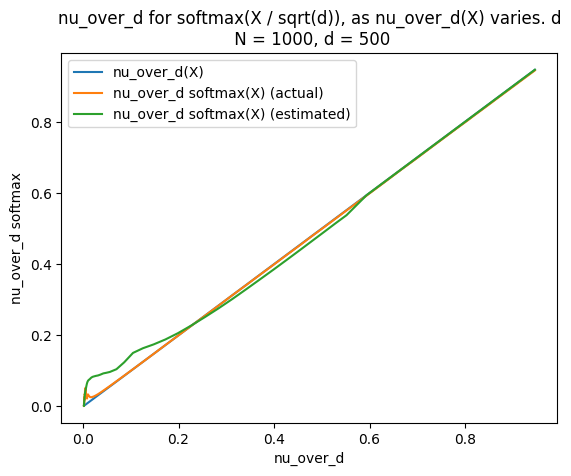

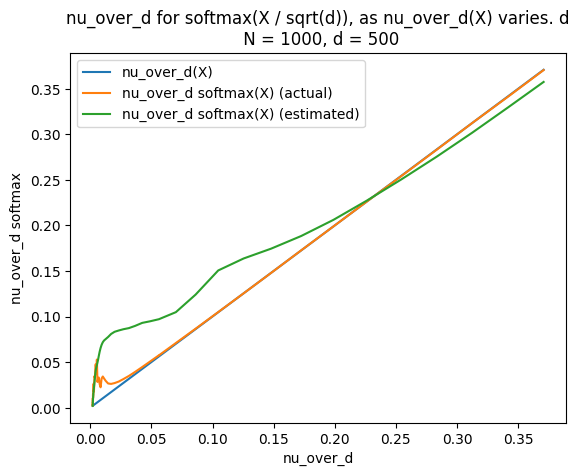

In [23]:

this_title = "nu_over_d for softmax(X / sqrt(d)), as nu_over_d(X) varies. d\n N = " + str(N) + ", d = " + str(d)

plt.plot(actual_nu_X_over_d_vals, actual_nu_X_over_d_vals, label = "nu_over_d(X)")
#actual_nu_softmaxX_over_d_vals
plt.plot(actual_nu_X_over_d_vals, actual_nu_softmaxX_over_d_vals, label = "nu_over_d softmax(X) (actual)")
plt.plot(actual_nu_X_over_d_vals, estimated_nu_softmaxX_over_d_vals, label = "nu_over_d softmax(X) (estimated)")
plt.xlabel("nu_over_d")
plt.ylabel("nu_over_d softmax")
plt.title(this_title)
plt.legend()
plt.show()


this_title = "nu_over_d for softmax(X / sqrt(d)), as nu_over_d(X) varies. d\n N = " + str(N) + ", d = " + str(d)

k = 70
plt.plot(actual_nu_X_over_d_vals[0:k], actual_nu_X_over_d_vals[0:k], label = "nu_over_d(X)")
#actual_nu_softmaxX_over_d_vals
plt.plot(actual_nu_X_over_d_vals[0:k], actual_nu_softmaxX_over_d_vals[0:k], label = "nu_over_d softmax(X) (actual)")
plt.plot(actual_nu_X_over_d_vals[0:k], estimated_nu_softmaxX_over_d_vals[0:k], label = "nu_over_d softmax(X) (estimated)")
plt.xlabel("nu_over_d")
plt.ylabel("nu_over_d softmax")
plt.title(this_title)
plt.legend()
plt.show()

# Now try N = 500, d = 1000

In [24]:
these_alphas = combined 
num_values = len(these_alphas)

alpha_vals = np.zeros(num_values)
implied_alpha_X_vals = np.zeros(num_values)
implied_alpha_softmaxX = np.zeros(num_values)
actual_nu_X_over_d_vals = np.zeros(num_values)
actual_alpha_softmaxX_vals = np.zeros(num_values)
estimated_alpha_softmaxX_vals = np.zeros(num_values)
actual_nu_softmaxX_over_d_vals = np.zeros(num_values)
estimated_nu_softmaxX_over_d_vals = np.zeros(num_values)

N = 500
d = 1000
uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False
use_svd = True

i = 0
for this_alpha in these_alphas:

  alpha_vals[i] = this_alpha

  X = pp.generate_data_manifold(N, d, this_alpha, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose, use_svd)

  actual_nu_X_over_d = pp.calculate_PatnaikPearson_dim(X) / d
  actual_nu_X_over_d_vals[i] = actual_nu_X_over_d

  implied_alpha_X = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_X_over_d, d)
  implied_alpha_X_vals[i] = implied_alpha_X

  softmaxX = pp.row_wise_softmax(X / math.sqrt(d))

  actual_nu_softmaxX_over_d = pp.calculate_PatnaikPearson_dim(softmaxX) / d
  actual_nu_softmaxX_over_d_vals[i] = actual_nu_softmaxX_over_d

  actual_alpha_softmaxX = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxX_over_d, d)
  actual_alpha_softmaxX_vals[i] = actual_alpha_softmaxX

  estimated_alpha_softmaxX = pp.calculate_softmax_alpha(implied_alpha_X)
  estimated_alpha_softmaxX_vals[i] = estimated_alpha_softmaxX

  estimated_nu_softmaxX_over_d = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxX, d)
  estimated_nu_softmaxX_over_d_vals[i] = estimated_nu_softmaxX_over_d

  print(i, "this_alpha = ", this_alpha)
  print(i, "implied_alpha_X = ", implied_alpha_X)
  print(i, "actual_alpha_softmaxX = ", actual_alpha_softmaxX)
  print(i, "estimated_alpha_softmaxX = ", estimated_alpha_softmaxX)
  print(i, "actual_nu_X_over_d = ", actual_nu_X_over_d)
  print(i, "actual_nu_softmaxX_over_d = ", actual_nu_softmaxX_over_d)
  print(i, "estimated_nu_softmaxX_over_d = ", estimated_nu_softmaxX_over_d)

  #print(i, this_alpha, implied_alpha_X,  actual_alpha_softmaxX, estimated_alpha_softmaxX, actual_nu_softmaxX_over_d, implied_nu_softmaxX_over_d)
  i +=1

generate_data_manifold: using svd
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 this_alpha =  0.05
0 implied_alpha_X =  1.0256158044014336
0 actual_alpha_softmaxX =  1.500067793193725
0 estimated_alpha_softmaxX =  1.1211140667260024
0 actual_nu_X_over_d =  0.054080184861792016
0 actual_nu_softmaxX_over_d =  0.27003974580125323
0 estimated_nu_softmaxX_over_d =  0.0829935914770139
generate_data_manifold: using svd
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
1 this_alpha =  0.060000000000000005
1 implied_alpha_X =  1.0682455429532358
1 actual_alpha_softmaxX =  1.522082736538322
1 estimated_alpha_softmaxX =  1.1728536805783245
1 actual_nu_X_over_d =  0.06592484254791561
1 actual_nu_softmaxX_over_d =  0.282980849987786
1 estimated_nu_softmaxX_over_d =  0.10225383830100883
generate_data_manifold: usin

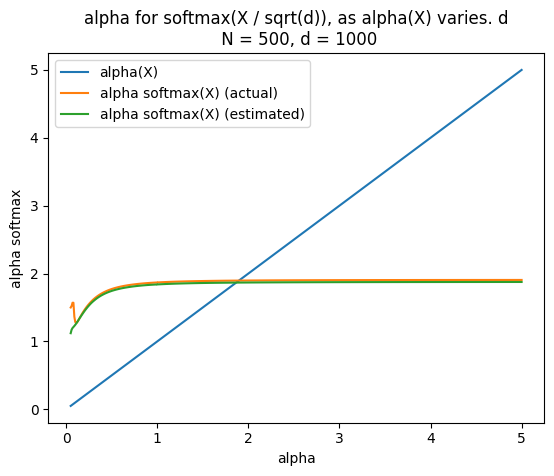

In [25]:
this_title = "alpha for softmax(X / sqrt(d)), as alpha(X) varies. d\n N = " + str(N) + ", d = " + str(d)

plt.plot(alpha_vals, alpha_vals, label = "alpha(X)")
plt.plot(alpha_vals, actual_alpha_softmaxX_vals, label = "alpha softmax(X) (actual)")
plt.plot(alpha_vals, estimated_alpha_softmaxX_vals, label = "alpha softmax(X) (estimated)")
plt.xlabel("alpha")
plt.ylabel("alpha softmax")
plt.title(this_title)
plt.legend()
plt.show()

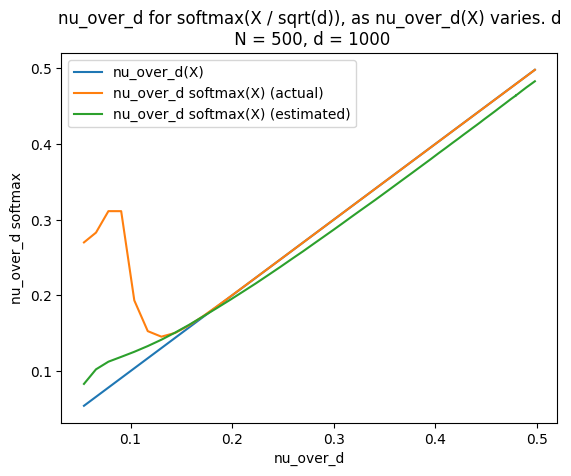

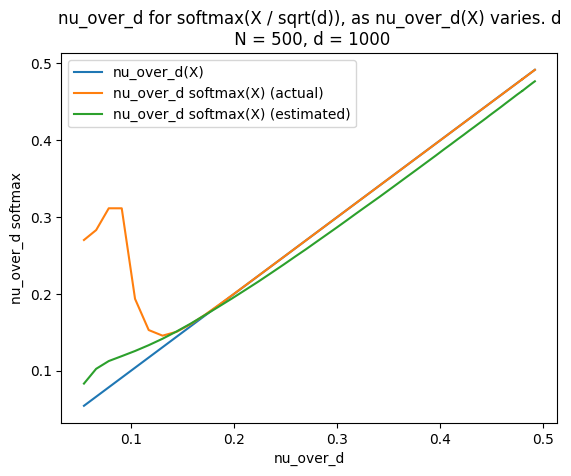

In [26]:
this_title = "nu_over_d for softmax(X / sqrt(d)), as nu_over_d(X) varies. d\n N = " + str(N) + ", d = " + str(d)

plt.plot(actual_nu_X_over_d_vals, actual_nu_X_over_d_vals, label = "nu_over_d(X)")
#actual_nu_softmaxX_over_d_vals
plt.plot(actual_nu_X_over_d_vals, actual_nu_softmaxX_over_d_vals, label = "nu_over_d softmax(X) (actual)")
plt.plot(actual_nu_X_over_d_vals, estimated_nu_softmaxX_over_d_vals, label = "nu_over_d softmax(X) (estimated)")
plt.xlabel("nu_over_d")
plt.ylabel("nu_over_d softmax")
plt.title(this_title)
plt.legend()
plt.show()


this_title = "nu_over_d for softmax(X / sqrt(d)), as nu_over_d(X) varies. d\n N = " + str(N) + ", d = " + str(d)

k = 70
plt.plot(actual_nu_X_over_d_vals[0:k], actual_nu_X_over_d_vals[0:k], label = "nu_over_d(X)")
#actual_nu_softmaxX_over_d_vals
plt.plot(actual_nu_X_over_d_vals[0:k], actual_nu_softmaxX_over_d_vals[0:k], label = "nu_over_d softmax(X) (actual)")
plt.plot(actual_nu_X_over_d_vals[0:k], estimated_nu_softmaxX_over_d_vals[0:k], label = "nu_over_d softmax(X) (estimated)")
plt.xlabel("nu_over_d")
plt.ylabel("nu_over_d softmax")
plt.title(this_title)
plt.legend()
plt.show()

## let nu/d vary between 0 and 1. 
## choose d randomly between 500 and 1000
## generate corresponding W
## calculate nu/d (W)
## calculate softmax(W), nu/d (softmax(W))

In [12]:
# combine these sets
arr1 = np.arange(0.0005, 0.02, 0.0005) # 40
arr2 = np.arange(0.02, 0.03, 0.001) # 10
arr3 = np.arange(0.03, 0.05, 0.002) # 10
arr4 = np.arange(0.05, 0.1, 0.005) # 10
arr5 = np.arange(0.1, 1.0, 0.05) # 18
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))

In [22]:
nu_over_d_vals = combined #np.arange(0.01, 1.0, 0.01)
num_iterations = len(nu_over_d_vals)
print("num_iterations = ", num_iterations)
scale_factor = 500

uniform_draws = True
use_pareto = True
use_uniform = False
use_cauchy = False
verbose = False
use_svd = True

d_vals = np.zeros(num_iterations)
alpha_vals = np.zeros(num_iterations)
actual_nu_W_over_d_vals = np.zeros(num_iterations)
implied_alpha_W_vals = np.zeros(num_iterations)
actual_nu_softmaxW_over_d_vals = np.zeros(num_iterations)
actual_alpha_softmaxW_vals = np.zeros(num_iterations)
estimated_alpha_softmaxW_vals = np.zeros(num_iterations) 
estimated_nu_softmaxW_over_d_using_alpha_softmaxW_vals = np.zeros(num_iterations)
estimated_nu_softmaxW_over_d_using_nu_W_over_d_vals = np.zeros(num_iterations)



for i in range(num_iterations):
    nu_over_d = nu_over_d_vals[i]
    d = int(scale_factor * (1.0 + np.random.uniform(0,1)))
    this_alpha = pp.calculate_alpha_given_nu_over_d_and_d(nu_over_d, d)

    d_vals[i] = d
    alpha_vals[i] = this_alpha

    W = pp.generate_square_weight_matrix(d, this_alpha, uniform_draws, use_pareto, use_uniform, use_cauchy, verbose)

    actual_nu_W_over_d = pp.calculate_PatnaikPearson_dim(W) / d
    actual_nu_W_over_d_vals[i] = actual_nu_W_over_d

    implied_alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_W_over_d, d)
    implied_alpha_W_vals[i] = implied_alpha_W

    softmaxW = pp.row_wise_softmax(W / math.sqrt(d))

    actual_nu_softmaxW_over_d = pp.calculate_PatnaikPearson_dim(softmaxW) / d
    actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d

    actual_alpha_softmaxW = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxW_over_d, d)
    actual_alpha_softmaxW_vals[i] = actual_alpha_softmaxW

    estimated_alpha_softmaxW = pp.calculate_softmax_alpha(implied_alpha_W)
    estimated_alpha_softmaxW_vals[i] = estimated_alpha_softmaxW

    estimated_nu_softmaxW_over_d_using_alpha_softmaxW = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxW, d)
    estimated_nu_softmaxW_over_d_using_alpha_softmaxW_vals[i] = estimated_nu_softmaxW_over_d_using_alpha_softmaxW

    estimated_nu_softmaxW_over_d_using_nu_W_over_d = pp.calculate_softmax_nu_over_d(actual_nu_W_over_d)
    estimated_nu_softmaxW_over_d_using_nu_W_over_d_vals[i] = estimated_nu_softmaxW_over_d_using_nu_W_over_d

    print(i, "this_alpha = ", this_alpha)
    print(i, "implied_alpha_W = ", implied_alpha_W)
    print(i, "actual_alpha_softmaxW = ", actual_alpha_softmaxW)
    print(i, "estimated_alpha_softmaxW = ", estimated_alpha_softmaxW)
    print(i, "actual_nu_W_over_d = ", actual_nu_W_over_d)
    print(i, "actual_nu_softmaxW_over_d = ", actual_nu_softmaxW_over_d)
    print(i, "estimated_nu_softmaxW_over_d_using_alpha_softmaxW = ", estimated_nu_softmaxW_over_d_using_alpha_softmaxW)
    print(i, "estimated_nu_softmaxW_over_d_using_nu_W_over_d = ", estimated_nu_softmaxW_over_d_using_nu_W_over_d)

    i +=1
    

num_iterations =  88
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 this_alpha =  0.13467744519959757
0 implied_alpha_W =  0.2950575977599189
0 actual_alpha_softmaxW =  0.3942199511096596
0 estimated_alpha_softmaxW =  0.38014201747398096
0 actual_nu_W_over_d =  0.0015086429918406785
0 actual_nu_softmaxW_over_d =  0.00257059004187951
0 estimated_nu_softmaxW_over_d_using_alpha_softmaxW =  0.0023883311324807066
0 estimated_nu_softmaxW_over_d_using_nu_W_over_d =  0.00918291015740937
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
1 this_alpha =  0.28644208784671693
1 implied_alpha_W =  0.33499975549806027
1 actual_alpha_softmaxW =  0.7164201684216371
1 estimated_alpha_softmaxW =  0.6712139991355424
1 actual_nu

In [ ]:
d_vals = np.zeros(num_iterations)
alpha_vals = np.zeros(num_iterations)
actual_nu_W_over_d_vals = np.zeros(num_iterations)
implied_alpha_W_vals = np.zeros(num_iterations)
actual_nu_softmaxW_over_d_vals = np.zeros(num_iterations)
actual_alpha_softmaxW_vals = np.zeros(num_iterations)
estimated_alpha_softmaxW_vals = np.zeros(num_iterations) 
estimated_nu_softmaxW_over_d_vals

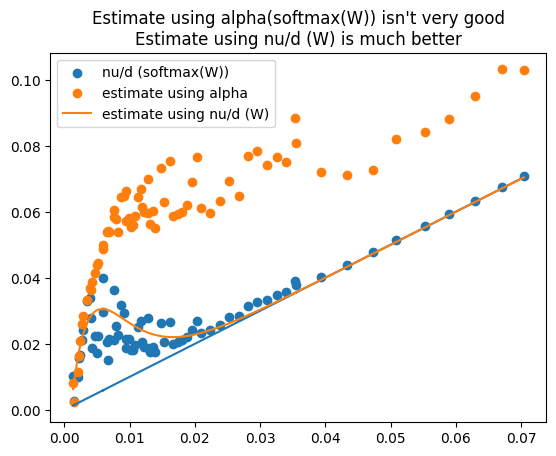

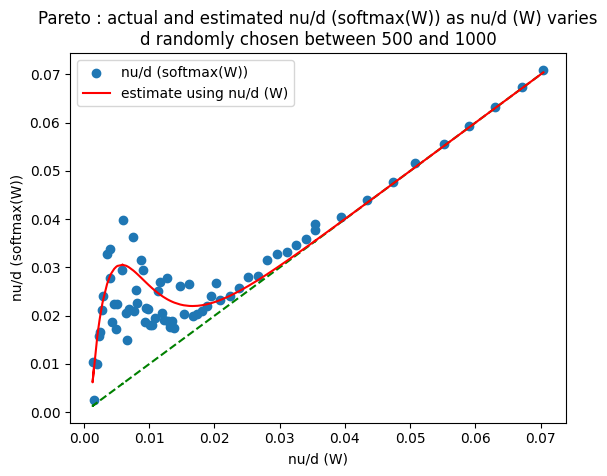

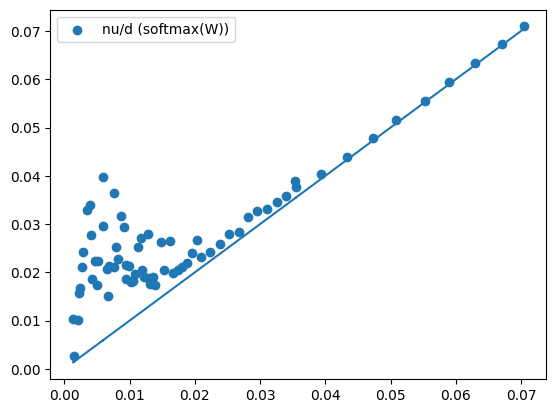

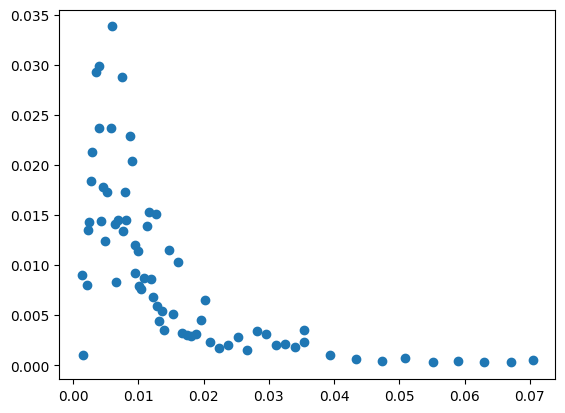

In [43]:
k = 70
this_title = "Estimate using alpha(softmax(W)) isn't very good\n"
this_title += "Estimate using nu/d (W) is much better"
plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k])
plt.scatter(actual_nu_W_over_d_vals[0:k], actual_nu_softmaxW_over_d_vals[0:k], label = "nu/d (softmax(W))")
plt.scatter(actual_nu_W_over_d_vals[0:k], estimated_nu_softmaxW_over_d_using_alpha_softmaxW_vals[0:k], label = "estimate using alpha")
plt.plot(actual_nu_W_over_d_vals[0:k], estimated_nu_softmaxW_over_d_using_nu_W_over_d_vals[0:k], label = "estimate using nu/d (W)")
plt.legend()
plt.title(this_title)
plt.show()

this_title = "Pareto : actual and estimated nu/d (softmax(W)) as nu/d (W) varies\n"
this_title += "d randomly chosen between 500 and 1000"
plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], color = "green", linestyle = "--")
plt.scatter(actual_nu_W_over_d_vals[0:k], actual_nu_softmaxW_over_d_vals[0:k], label = "nu/d (softmax(W))")
#plt.scatter(actual_nu_W_over_d_vals[0:k], estimated_nu_softmaxW_over_d_using_alpha_softmaxW_vals[0:k], label = "estimate using alpha")
plt.plot(actual_nu_W_over_d_vals[0:k], estimated_nu_softmaxW_over_d_using_nu_W_over_d_vals[0:k], 
         color = "red", label = "estimate using nu/d (W)")
plt.xlabel("nu/d (W)")
plt.ylabel("nu/d (softmax(W))")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_softmaxW_actual_vs_estimated_as_nu_over_d_W_varies_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

k = 70
plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k])
plt.scatter(actual_nu_W_over_d_vals[0:k], actual_nu_softmaxW_over_d_vals[0:k], label = "nu/d (softmax(W))")
#plt.scatter(actual_nu_W_over_d_vals[0:k], estimated_nu_softmaxW_over_d_vals[0:k])
plt.legend()
plt.show()

diff_vals = actual_nu_softmaxW_over_d_vals - actual_nu_W_over_d_vals
plt.scatter(actual_nu_W_over_d_vals[0:k], diff_vals[0:k])
plt.show()
